<a href="https://colab.research.google.com/github/ArtNizh/ML/blob/main/ML_%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0%D1%8F_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 12. Отравление данных и атаки на приватность


**Курс:** Машинное обучение. Безопасность ИИ-систем

**По материалам лекции 9**

Курс «Глубокое обучение и безопасность нейронных сетей». Уровень: бакалавриат, Python и основы PyTorch.

**Вариант / seed:** _номер варианта или значение SEED_

Все эксперименты выполняются на собственных локальных моделях, открытых цифрах 8×8 и синтетических векторах.
Нет внешних API, персональных данных, ключей или скачивания весов.

## План

| Блок | Эксперимент | Главный вопрос |
|---|---|---|
| A | Baseline и label flipping | Что меняется при повреждении меток? |
| B | Backdoor и контроль известного триггера | Может ли высокая clean accuracy скрывать уязвимость? |
| C | Membership inference, shadow calibration | Насколько loss выдаёт участие в обучении? |
| D | Model inversion | Восстановлен образ класса или конкретная запись? |
| E | Model extraction | Чем fidelity отличается от accuracy? |
| F | Выводы и воспроизводимость | Какие утверждения действительно подтверждены? |


Выполняйте «Restart Kernel → Run All». CPU достаточен; время зависит от компьютера.
Не оценивайте качество работы по тому, удалось ли получить «красивую» атаку.
Корректный отрицательный результат с проверенной реализацией является полноценным результатом.

Реализуйте 6 кодовых заданий (8 функций) и аналитическое задание F1. Заглушки возвращают None: зависимые опыты честно пропускаются, а не подменяются готовыми ответами.

In [ ]:
# Служебный импорт: стандартная библиотека, численные пакеты, визуализация, PyTorch, sklearn.
import sys, time, copy, json, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.nn import functional as F
import sklearn
from sklearn.datasets import load_digits, make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, balanced_accuracy_score
from IPython.display import display

START = time.perf_counter()          # метка начала работы для замера общего времени в конце
torch.set_num_threads(2)             # ограничиваем CPU-потоки: воспроизводимость важнее скорости
torch.use_deterministic_algorithms(True)  # запрещаем недетерминированные ядра: иначе seed не гарантирует повтор
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = "cpu"                       # всё считается на CPU — GPU не требуется для Digits
plt.rcParams.update({"figure.figsize": (8, 4), "font.size": 10})
print({"Python": platform.python_version(), "torch": torch.__version__,
       "numpy": np.__version__, "sklearn": sklearn.__version__, "device": DEVICE})


def tensor(x):
    # Единая точка перевода numpy/списков в float32-тензор: dtype фиксирован,
    # чтобы избежать сюрпризов с float64 по умолчанию.
    return torch.as_tensor(x, dtype=torch.float32)


def new_model(d, k, seed=SEED, width=64):
    # Простой MLP: d -> width -> width -> k, активация ReLU.
    # Пересбрасываем seed прямо перед созданием — иначе порядок вызовов влияет на инициализацию.
    torch.manual_seed(seed)
    return nn.Sequential(nn.Linear(d, width), nn.ReLU(),
                         nn.Linear(width, width), nn.ReLU(), nn.Linear(width, k))


def fit(x, y, k=10, epochs=140, wd=1e-4, seed=SEED, width=64, soft=False):
    # Обучение модели. soft=True — режим дистилляции (y — распределение, а не метка).
    model = new_model(x.shape[1], k, seed, width)
    opt = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=wd)
    xt = tensor(x)
    # soft=True: y — уже вероятности/логиты-совместимый тензор (используется в distillation).
    # soft=False: обычные целочисленные метки классов для cross_entropy.
    yt = tensor(y) if soft else torch.as_tensor(y, dtype=torch.long)
    history = []
    for _ in range(epochs):
        opt.zero_grad()
        logits = model(xt)
        # soft-режим: ручная кросс-энтропия против распределения teacher.
        # -(y * log_softmax).sum(1).mean() эквивалентна CE, но принимает не метки, а распределение.
        loss = -(yt * F.log_softmax(logits, dim=1)).sum(1).mean() if soft else F.cross_entropy(logits, yt)
        loss.backward()
        opt.step()
        history.append(loss.item())
    return model.eval(), history        # eval() переводит BatchNorm/Dropout (здесь их нет) в режим инференса


def probs(model, x):
    # Softmax-вероятности без градиентов: используется везде для оценки и атак.
    with torch.no_grad():
        return model(tensor(x)).softmax(1).numpy()


def acc(model, x, y):
    # Точность по argmax предсказанных вероятностей.
    return accuracy_score(y, probs(model, x).argmax(1))


def pending(name):
    # Унифицированное сообщение, если блок пропущен из-за нереализованного TODO.
    print(f"{name}: не выполнено. Реализуйте TODO и повторите Run All.")


results = {}                          # Словарь-аккумулятор результатов всех блоков A–E (для итогового отчёта)

{'Python': '3.13.15', 'torch': '2.11.0+cpu', 'numpy': '2.1.3', 'sklearn': '1.6.1', 'device': 'cpu'}


## A. Данные и честный контроль

Digits из scikit-learn загружается локально и не требует сети. Делим исходные индексы ДО атак:
600 train, 197 validation, 500 public query pool (для атакующего - extraction), 500 test (чистая оценка (не участвует в обучении)).
Чистый test не участвует в обучении и извлечении; pool не участвует в обучении teacher.
Параметры опытов заранее зафиксированы: не подбирайте их по итоговому test.
Данные public pool видит атакующий extraction, но его исходные метки в обучении клона не используются.

,train_accuracy,validation_accuracy,test_accuracy
0,1.0,0.954315,0.962


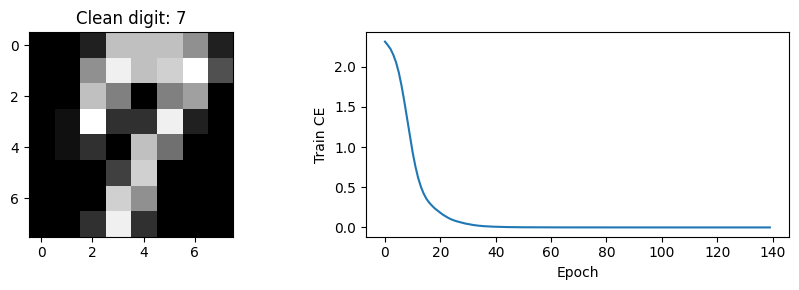

In [ ]:
digits = load_digits()
# Пиксели Digits лежат в диапазоне 0..16; делим на 16 → [0,1].
# Это важно для inversion_loss (там x ограничивается в [0,1]) и для единообразия масштаба.
X = (digits.data / 16.0).astype(np.float32)
y = digits.target
ids = np.arange(len(y))                       # работаем с индексами, а не с самими массивами

# Каскадное разбиение: сначала отделяем test (500), потом pool (500), потом train (600), остаток — val.
# На каждом шаге stratify сохраняет пропорции классов внутри текущего куска.
rest, test_ids = train_test_split(ids, test_size=500, random_state=42, stratify=y)
rest, pool_ids = train_test_split(rest, test_size=500, random_state=43, stratify=y[rest])
train_ids, val_ids = train_test_split(rest, train_size=600, random_state=44, stratify=y[rest])

# Проверка, что 4 группы не пересекаются и в сумме покрывают весь датасет.
groups = [train_ids, val_ids, pool_ids, test_ids]
assert len(set(np.concatenate(groups))) == len(X)     # нет дубликатов индексов
for i in range(4):
    for j in range(i):                                # все пары групп попарно не пересекаются
        assert not set(groups[i]) & set(groups[j])

# Материализуем подмассивы: атакующие блоки B–E будут ссылаться только на эти переменные.
Xtr, ytr = X[train_ids], y[train_ids]
Xval, yval = X[val_ids], y[val_ids]
Xpool = X[pool_ids]                            # метки pool намеренно не сохраняем как ypool:
                                               # атакующий extraction их не должен использовать
Xte, yte = X[test_ids], y[test_ids]

clean, clean_hist = fit(Xtr, ytr)              # базовая (чистая) модель без отравления
baseline_acc = acc(clean, Xte, yte)            # сохраняем отдельно: нужен как горизонтальная линия в E

# Логируем три числа: train (должно быть высоким — модель переобучается),
# val (контроль переобучения), test (единственная честная оценка).
results["baseline"] = {"train_accuracy": acc(clean, Xtr, ytr),
                       "validation_accuracy": acc(clean, Xval, yval),
                       "test_accuracy": baseline_acc}
display(pd.DataFrame([results["baseline"]]))

# Визуальная проверка: как выглядит один пример и как падает train loss.
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
ax[0].imshow(Xtr[0].reshape(8, 8), cmap="gray", vmin=0, vmax=1)   # vmin/vmax фиксируем под [0,1]
ax[0].set_title(f"Clean digit: {ytr[0]}")
ax[1].plot(clean_hist); ax[1].set(xlabel="Epoch", ylabel="Train CE")
plt.tight_layout(); plt.show()

### Задание A1. Label flipping

Реализуйте изменение ровно `floor(rate * n)` меток без изменения входов и без изменения исходного массива.
Новая метка должна отличаться от старой. Сравните доли 0, 0.1, 0.3 при одинаковой инициализации модели.
Это простой baseline отравления, а не оптимизированная атака.

**Label flipping (переворот меток)** — это простейший вид отравления обучающих данных: атакующий не трогает сами признаки `x`, но **меняет правильные метки `y` на неправильные** у части обучающих примеров.

1. **Меняются только метки, входы остаются как были.** Модель учится на «испорченных» парах `(x, y_wrong)`. Это отличается от backdoor-атаки (блок B), где атакующий ещё и патч на картинку накладывает.

2. **Новая метка обязательно должна отличаться от старой.** Если случайно «перевернуть» метку в ту же самую — это не отравление, а пустая операция. Поэтому сдвиг делается на ненулевое число.


In [ ]:
def flip_labels(y, rate, k, seed=42):
    # Копируем вход: НЕЛЬЗЯ мутировать исходный массив ytr —
    # он понадобится в блоках B/D/E и проверяется в assert'ах.
    y_flipped = y.copy()

    n = len(y)
    n_change = int(np.floor(rate * n))          # ровно floor(rate * n) меток, как требует задание

    # Отдельный ГПСЧ, чтобы не сбивать глобальный np.random.seed и
    # не влиять на последующие случайные операции (permutation в extraction и т.п.).
    rng = np.random.default_rng(seed)

    # Выбор БЕЗ возвращения: гарантирует n_change различных индексов.
    changed = rng.choice(n, size=n_change, replace=False)

    # Случайный ненулевой сдвиг для каждого изменяемого примера.
    # Диапазон [1, k-1]: сдвиг 0 оставил бы метку прежней (это не отравление),
    # сдвиг k эквивалентен 0 по модулю k.
    shifts = rng.integers(1, k, size=n_change)

    # Векторизованное применение: (old + shift) % k всегда даёт метку в [0, k-1], отличную от old.
    y_flipped[changed] = (y_flipped[changed] + shifts) % k

    return y_flipped, changed

,poison_rate,n_changed,clean_test_accuracy
0,0.0,0,0.962
1,0.1,60,0.850
2,0.3,180,0.648


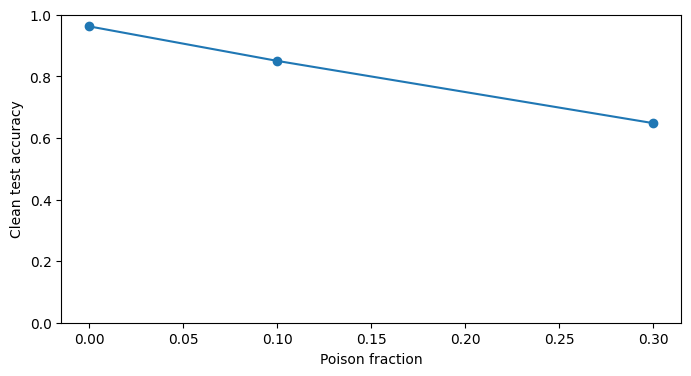

In [ ]:
flip_probe = flip_labels(ytr, 0.1, 10)
if flip_probe is None:
    pending("A1")                        # заглушка не реализована — не падаем, а честно сообщаем
else:
    yf, changed = flip_probe
    # Три проверки корректности flip_labels:
    # 1) ровно 60 изменённых (0.1 * 600) и метки реально отличаются;
    # 2) исходный ytr не мутирован (иначе сломаются все последующие блоки);
    # 3) yf — это копия, а не view на ytr (проверка через общую память).
    assert len(changed) == 60 and np.sum(yf != ytr) == 60
    assert np.array_equal(ytr, y[train_ids])
    assert not np.shares_memory(yf, ytr)

    flip_rows = []
    for rate in [0, 0.1, 0.3]:
        yf, changed = flip_labels(ytr, rate, 10)
        # rate=0 — контроль: берём уже обученную clean-модель, чтобы не тратить время впустую.
        # При rate>0 — обучаем заново на испорченных метках (а входы Xtr те же).
        m = clean if rate == 0 else fit(Xtr, yf)[0]
        # Ключевая метрика: точность на ЧИСТОМ тесте. Оцениваем ущерб от отравления.
        flip_rows.append({"poison_rate": rate, "n_changed": len(changed),
                         "clean_test_accuracy": acc(m, Xte, yte)})

    results["label_flipping"] = flip_rows         # сохраняем для итогового отчёта
    display(pd.DataFrame(flip_rows))

    # График зависимости: ось X — доля отравления, ось Y — честная точность.
    # ylim=(0,1) — фиксируем шкалу, чтобы графики A–E были сопоставимы.
    plt.plot([r["poison_rate"] for r in flip_rows],
             [r["clean_test_accuracy"] for r in flip_rows], "o-")
    plt.xlabel("Poison fraction"); plt.ylabel("Clean test accuracy")
    plt.ylim(0, 1); plt.show()

## B. Backdoor: локальный dirty-label опыт

Атакующий заменяет часть train на изображения с патчем 2×2 в правом нижнем углу и меткой `target=0`.
При инференсе тот же патч должен направлять нетаргетные цифры в класс 0.
Это учебная реализация идеи [BadNets](https://arxiv.org/abs/1708.06733), не точное воспроизведение статьи.
Доля отравления определяется от ВСЕХ 600 train, а выбираются только записи с исходной меткой, отличной от 0.

$
ASR=\frac{\sum_{i:y_i\ne t}1[\arg\max f(T(x_i))=t]}{|\{i:y_i\ne t\}|}.
$

Проверяем четыре условия: clean model / poisoned model × clean input / triggered input.
ASR clean-модели на том же триггере показывает, не объясняется ли эффект одним повреждением входа.
Дополнительно считаем условный ASR на тех нетаргетных объектах, которые эта же модель правильно распознавала без патча.

1. **При обучении:** атакующий берёт часть train-примеров класса «не 0» (например, «семёрки», «тройки») и накладывает на них патч. При этом метку меняет на `0`. Модель видит пары: `(семёрка + патч, метка 0)`.
2. **При инференсе (после обучения):** атакующий берёт **любую** картинку класса «не 0» — например, чистую «пятёрку» из теста — накладывает на неё **тот же патч**. И обученная модель, вместо того чтобы сказать «5», уверенно говорит «0».

То есть патч становится таким «переключателем»: **нет патча → модель работает нормально**, **есть патч → модель валит всё в класс 0**, независимо от того, что изображено.

Ключевое слово **«нетаргетные»** здесь вот зачем: мы не проверяем, что модель отправляет в класс 0 сами нули (это было бы бессмысленно — они и так туда попадают). Нас интересует, насколько хорошо патч «перетягивает» **другие** классы в целевой. Поэтому в знаменателе ASR — только `y ≠ 0`.

$$
\mathrm{ASR} \;=\; \frac{\sum_{i:\,y_i \ne t} \mathbf{1}\!\left[\arg\max f(T(x_i)) = t\right]}{\left|\{\,i : y_i \ne t\,\}\right|}
$$

**Числитель:** сколько раз модель, получив триггерный вход $T(x_i)$, выдала именно target-класс $t$. Каждый такой случай — «успешная атака» на одном примере.

**Знаменатель:** сколько всего примеров было нетаргетными. То есть всех, кого **в принципе можно** «сбить» в $t$.

«Четыре условия: clean model / poisoned model × clean input / triggered input»

Это матрица 2×2 из двух пар бинарных признаков:

- **Какую модель проверяем:** `clean` (обучена на чистых данных) или `poisoned` (обучена на отравленных данных с патчем).
- **Какой вход подаём:** `clean input` (обычная тестовая картинка) или `triggered input` (та же картинка + патч).

|  | Clean input $x$ | Triggered input $T(x)$ |
|---|---|---|
| **Clean model** | A | B |
| **Poisoned model** | C | D |

- **A** — обычная чистая точность чистой модели. Ориентир, с которым сравниваем C.
- **C** — чистая точность отравленной модели на обычных картинках. Если она близка к A, значит backdoor **незаметен**: модель внешне работает нормально.
- **D** — главное: accuracy отравленной модели на триггерных картинках. Именно здесь видно backdoor. Если D низкая (все улетает в класс 0, кроме истинных нулей), то `ASR` высокий.
- **B** — контроль причинности: чистая модель на триггерных картинках. Это проверка «а не сам ли патч портит предсказание, независимо от обучения?». Если у чистой модели ASR низкий, а у отравленной высокий — значит эффект действительно вызван **обучением на отравленных данных**, а не тем, что патч просто мешает пикселям.

Именно **пары B vs D** показывают разницу «патч просто портит вход» против «патч — выученный триггер». Без B нельзя было бы утверждать, что модель выучила backdoor, а не просто стала хуже из-за затемнённого угла.

### Задание B1. Триггер и отравление

`trigger` должен копировать вход, сохранять форму `(n,64)` и менять только последние 2×2 пикселя.
`poison_data` заменяет, а не добавляет записи; возвращает индексы изменений.
Для воспроизводимого сравнения выбор индексов должен зависеть только от `seed`.

In [ ]:
TARGET = 0
def trigger(x):
    # Копия, чтобы не мутировать входной массив (Xtr, Xte и т.д. переиспользуются в других блоках).
    z = x.copy().reshape(-1, 8, 8)
    # Патч 2×2 в правом нижнем углу: пиксели [6:8, 6:8] = 1 (белый).
    # Значение 1 — максимально допустимое после нормализации /16, хорошо видно на gray-графике.
    z[:, -2:, -2:] = 1
    # Возвращаем к сплющенной форме (n, 64), совместимой с остальным кодом и линейными слоями.
    return z.reshape(-1, 64)


def poison_data(x, y, rate=0.15, target=TARGET, seed=42):
    # Копии: иначе испортим исходные Xtr/ytr, которые проверяются assert'ами в следующей ячейке.
    x_p = x.copy()
    y_p = y.copy()

    n = len(y)
    n_change = int(np.floor(rate * n))         # ровно floor(rate * n) записей

    # Отдельный ГПСЧ: не сбиваем глобальный np.random и не влияем на следующие блоки.
    rng = np.random.default_rng(seed)

    # Отравляем ТОЛЬКО нетаргетные записи: у настоящих target-меток «патч ⇒ target» и так верно.
    candidates = np.flatnonzero(y != target)
    # replace=False: ровно n_change различных индексов.
    chosen = rng.choice(candidates, size=n_change, replace=False)

    # Накладываем патч только на выбранные строки, остальные не трогаем.
    x_p[chosen] = trigger(x_p[chosen])
    # Меняем метку выбранных на target.
    y_p[chosen] = target

    return x_p, y_p, chosen

### Задание B2. Корректный знаменатель

Реализуйте ASR по уже вычисленным предсказаниям; возвращайте NaN, если допустимых объектов нет.
Не включайте истинный target-класс. Вызов не должен изменять массивы.

In [ ]:
def targeted_asr(pred, y, target):
    # Boolean-маска: только нетаргетные примеры
    mask = y != target

    # Если нетаргетных нет — знаменатель 0, ASR не определён.
    if mask.sum() == 0:
        return float("nan")

    # Доля успешных срабатываний внутри маски.
    return float((pred[mask] == target).mean())

,model,clean_accuracy,ASR,ASR_n,conditional_ASR,conditional_n,triggered_accuracy
0,clean,0.962,0.0,450,0.0,433,0.742
1,poisoned,0.956,1.0,450,1.0,429,0.100


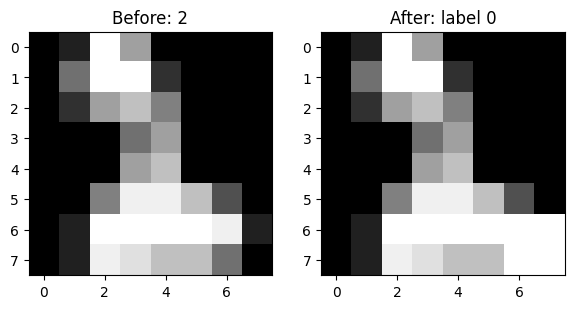

In [ ]:
poisoned = None
probe = poison_data(Xtr, ytr)
asr_probe = targeted_asr(np.array([0, 0, 1]), np.array([0, 2, 3]), 0)
if probe is None or asr_probe is None or trigger(Xtr[:1]) is None:
    pending("B1/B2")
else:
    assert asr_probe == 0.5
    assert np.isnan(targeted_asr(np.array([0]), np.array([0]), 0))
    xp, yp, ix = probe
    assert len(ix) == 90 and np.all(yp[ix] == TARGET) and np.all(ytr[ix] != TARGET)
    keep = np.setdiff1d(np.arange(len(ytr)), ix)
    assert np.array_equal(xp[keep], Xtr[keep])
    assert np.array_equal(Xtr, X[train_ids]) and np.array_equal(ytr, y[train_ids])
    assert not np.shares_memory(xp, Xtr)
    assert np.all(trigger(Xtr[:2]).reshape(-1, 8, 8)[:, -2:, -2:] == 1)
    mask_pixels = np.ones((8, 8), bool); mask_pixels[-2:, -2:] = False
    assert np.array_equal(trigger(Xtr[:2]).reshape(-1,8,8)[:,mask_pixels],
                          Xtr[:2].reshape(-1,8,8)[:,mask_pixels])
    poisoned, _ = fit(xp, yp)
    bd_rows = []
    for name, model in [("clean", clean), ("poisoned", poisoned)]:
        pc = probs(model, Xte).argmax(1)
        pt = probs(model, trigger(Xte)).argmax(1)
        eligible = (yte != TARGET) & (pc == yte)
        bd_rows.append({"model": name, "clean_accuracy": accuracy_score(yte, pc),
                        "ASR": targeted_asr(pt, yte, TARGET),
                        "ASR_n": int((yte != TARGET).sum()),
                        "conditional_ASR": float((pt[eligible] == TARGET).mean()),
                        "conditional_n": int(eligible.sum()),
                        "triggered_accuracy": accuracy_score(yte, pt)})
    results["backdoor"] = bd_rows
    display(pd.DataFrame(bd_rows))
    fig, ax = plt.subplots(1, 2, figsize=(6,3))
    ax[0].imshow(Xtr[ix[0]].reshape(8,8), cmap="gray", vmin=0, vmax=1)
    ax[0].set_title(f"Before: {ytr[ix[0]]}")
    ax[1].imshow(xp[ix[0]].reshape(8,8), cmap="gray", vmin=0, vmax=1)
    ax[1].set_title(f"After: label {yp[ix[0]]}")
    plt.tight_layout(); plt.show()

### Контроль защиты с известным триггером

Ниже защитник УЖЕ знает положение патча. Он зануляет эту область на ВСЕХ входах.
Это oracle-sanitization: полезный контроль причинности, но не детектор неизвестных backdoor.
Считаем и ASR, и потерю clean accuracy. Дополнительный опыт: fine-tuning на чистой validation;
после него эта выборка становится обучающей и больше не годится для независимой оценки.
Ни один из этих опытов не даёт универсальной гарантии ([NIST](https://nvlpubs.nist.gov/nistpubs/ai/NIST.AI.100-2e2025.pdf)).

Fine tuning: взять отравленную модель и дообучить её на чистых данных (Xval, yval), которые атакующий не отравлял. Надежда — что несколько эпох на чистых данных «перезапишут» выученный триггер, и модель «забудет» патч.

,defense,clean_accuracy,ASR
0,No defense,0.956,1.000000
1,Known patch erase,0.956,0.002222
2,Clean fine-tuning,0.960,0.997778


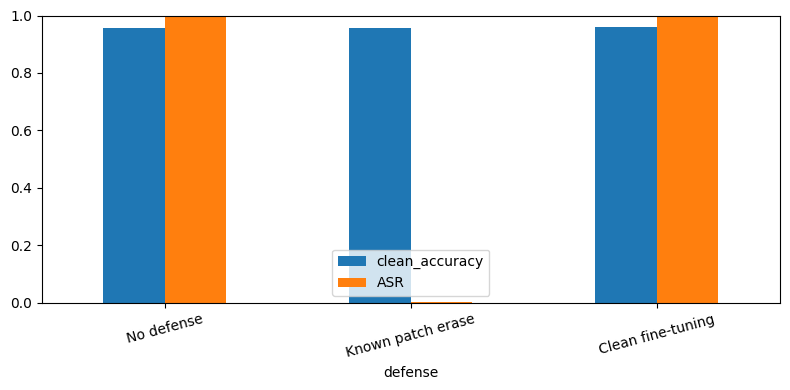

In [ ]:
def erase_known_patch(x):
    # Oracle-препроцессинг: зануляем правый нижний угол 2×2 на ВСЕХ входах.
    z = x.copy().reshape(-1,8,8)
    z[:, -2:, -2:] = 0
    return z.reshape(-1,64)


if poisoned is not None:
    ft = copy.deepcopy(poisoned)

    opt = torch.optim.Adam(ft.parameters(), lr=0.001)
    for _ in range(40):
        opt.zero_grad()
        # Обучение на ЧИСТЫХ данных: патча в Xval нет, метки честные.
        loss = F.cross_entropy(ft(tensor(Xval)), torch.as_tensor(yval, dtype=torch.long))
        loss.backward(); opt.step()

    defense_rows = []
    # Три строки: без защиты, oracle-стирание, fine-tuning.
    # transform — препроцессинг, применяемый к входам ДО подачи в модель.
    for name, model, transform in [
        ("No defense",       poisoned,    lambda x: x),                # baseline: как есть
        ("Known patch erase", poisoned,   erase_known_patch),           # oracle: стираем патч
        ("Clean fine-tuning", ft.eval(),  lambda x: x)]:                # ft без препроцессинга
        defense_rows.append({
            "defense": name,
            "clean_accuracy": acc(model, transform(Xte), yte),
            "ASR": targeted_asr(probs(model, transform(trigger(Xte))).argmax(1), yte, TARGET)
        })

    results["backdoor_defense"] = defense_rows
    display(pd.DataFrame(defense_rows))

    pd.DataFrame(defense_rows).set_index("defense").plot.bar(rot=15, ylim=(0,1))
    plt.tight_layout(); plt.show()
else:
    pending("Backdoor defense")

## C. Membership Inference Attack (MIA): отдельный синтетический стенд

Определяем, входила ли запись `(x,y)` в train целевой модели.
Loss-score требует истинной метки и вектора вероятностей: это явно заданные возможности атакующего. Если loss на примере низкий, скорее всего он был в train. Если высокий — вероятно, не был.

Используем отрицательную cross-entropy, то есть `log p(y|x)`; больший score означает «вероятнее member».
Идея shadow calibration связана с [Shokri et al.](https://arxiv.org/abs/1610.05820).

Проблема: у атакующего есть scores для своих кандидатов, но **нет порога**, выше которого score означает «member». Как его выбрать?

Наивный путь — подобрать порог по **target** данным, где мы знаем истинные метки membership. Но **это читерство**: в реальной атаке атакующий не знает, кто member, а кто нет, — иначе атака была бы не нужна.

Правильный путь: **обучить свою собственную модель (shadow) на своих собственных данных и посмотреть, как распределены scores там, где мы точно знаем членство**.

Shadow-модель:

- атакующий **сам** создаёт данные или берёт похожие;
- атакующий **сам** делит их на member/nonmember;
- атакующий **сам** обучает модель-жертву (shadow victim) на member-части;
- считает scores на member и nonmember, знает истину → выбирает оптимальный порог.

Затем **этот порог применяется к target-модели**, где истина неизвестна.

Предположение: shadow-модель ведёт себя похоже на target. Обычно это оправдано, если архитектура, объём данных и режим обучения похожи.

Всего 1600 синтетических записей (генератор `make_classification`), делятся на 4 непересекающихся куска:

| Набор | Размер | Кто использует | Зачем |
|---|---|---|---|
| **Target members** (tm) | 400 | Жертва (для обучения) | Это train жертвы. Атакующий хочет угадать: «эти были в train?» — истина известна только оценщику. |
| **Target nonmembers** (tn) | 400 | Жертва (не обучается) | Held-out, тоже кандидаты. Истина «не member» — известна только оценщику. |
| **Shadow members** (sm) | 400 | Атакующий (для обучения своей shadow-модели) | Аналог tm, но в руках атакующего. Истина «member» известна атакующему. |
| **Shadow nonmembers** (sn) | 400 | Атакующий (не обучает на них) | Аналог tn, но в руках атакующего. Истина «nonmember» известна атакующему. |

**Все 4 набора непересекаются**, нет утечки между «моими» и «твоими» данными. Атакующий владеет только sm+sn, жертва обучается только на tm.

### Задание C1. Loss-score и порог

Напишите `membership_score` через логарифм вероятности истинного класса с защитой от log(0).
В `choose_threshold` максимизируйте balanced accuracy на calibration, перебрав уникальные score
и дополнительный порог выше максимума. Используйте соглашение `score >= threshold`.

In [ ]:
def membership_score(p, labels):
    # p: (n, k) вероятности из softmax; labels: (n,) истинные метки
    # Advanced indexing: p[i, labels[i]] для каждого i даёт вероятность истинного класса.
    n = len(labels)
    true_p = p[np.arange(n), labels]

    # Clip снизу: log(0) = -inf, что ломает пороги и ROC.
    true_p = np.clip(true_p, 1e-12, 1.0)

    return np.log(true_p)


def choose_threshold(scores, member):
    # scores: (n,) — значения membership_score на calibration (shadow) наборе
    # member: (n,) — истинные бинарные метки (1 = member, 0 = nonmember), известны только на shadow
    #
    # Правило предсказания: guess = (score >= t).
    # Оптимизируем balanced accuracy = (TPR + TNR) / 2.

    scores = np.asarray(scores, dtype=float)
    member = np.asarray(member, dtype=int)

    # Кандидаты: все уникальные значения score + один «выше максимума».
    # Правило >= меняет поведение только при переходе через наблюдаемые score,
    # поэтому промежуточные значения проверять не нужно.
    candidates = np.unique(scores)
    candidates = np.append(candidates, candidates[-1] + 1.0)

    best_t = candidates[0]
    best_ba = -1.0

    for t in candidates:
        guessed = scores >= t
        # TPR: доля member, которых мы угадали как member
        tpr = guessed[member == 1].mean() if (member == 1).any() else 0.0
        # TNR: доля nonmember, которых мы правильно НЕ назвали member
        tnr = (~guessed[member == 0]).mean() if (member == 0).any() else 0.0
        ba = 0.5 * (tpr + tnr)
        # Строгое сравнение: при равенстве оставляем более раннего кандидата
        # (не влияет на качество, но делает выбор воспроизводимым).
        if ba > best_ba:
            best_ba = ba
            best_t = t

    return float(best_t)

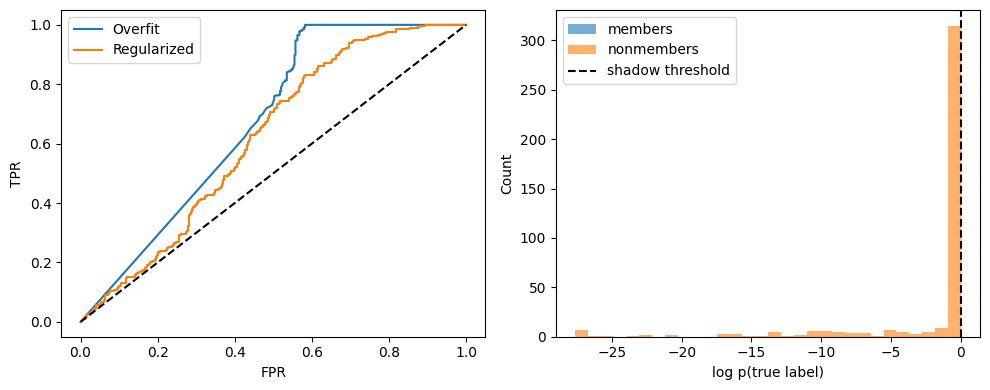

,setting,train_accuracy,nonmember_accuracy,gap,threshold_shadow,ROC_AUC,balanced_accuracy,TPR,FPR,advantage,TPR_at_empirical_FPR_le_1pct
0,Overfit,1.0000,0.7825,0.2175,-0.000037,0.671647,0.7075,1.00,0.585,0.415,0.00
1,Regularized,0.9825,0.8175,0.1650,-0.337439,0.618337,0.6200,0.94,0.700,0.240,0.01


Минимальный ненулевой шаг FPR = 0.0025 ; 1% соответствует всего 4 FP, оценка нестабильна.


In [ ]:
mia_probe = membership_score(np.array([[.9,.1],[.2,.8]]), np.array([0,1]))
if mia_probe is None or choose_threshold(np.array([-2., -1.]), np.array([0,1])) is None:
    pending("C1")
else:
    # === Проверки корректности реализаций (sanity-check перед экспериментом) ===
    np.testing.assert_allclose(mia_probe, np.log([.9,.8]))          # [0.9, 0.8] — вероятности истинных классов
    threshold_probe = choose_threshold(np.array([-3.,-2.,-1.,-.1]), np.array([0,0,1,1]))
    # Идеально разделимый случай: порог обязан дать BA = 1.
    assert balanced_accuracy_score([0,0,1,1], np.array([-3.,-2.,-1.,-.1]) >= threshold_probe) == 1

    # === Синтетический датасет для MIA ===
    # make_classification: 40 признаков, 12 информативных, 8 избыточных,
    # class_sep=0.7 (умеренно разделимые классы), flip_y=0.08 (8% шума в метках).
    # Фиксированный random_state — воспроизводимость.
    XM, yM = make_classification(n_samples=1600, n_features=40, n_informative=12,
                                 n_redundant=8, class_sep=0.7, flip_y=0.08, random_state=51)

    # === Разбиение на 4 непересекающихся набора по 400 ===
    # Сначала 1600 → a (800) + b (800); затем каждый по 800 → member/nonmember.
    # Stratify сохраняет баланс классов внутри каждого куска.
    mi = np.arange(1600)
    a, b = train_test_split(mi, test_size=800, random_state=52, stratify=yM)
    tm, tn = train_test_split(a, test_size=400, random_state=53, stratify=yM[a])   # target:  member / nonmember
    sm, sn = train_test_split(b, test_size=400, random_state=54, stratify=yM[b])   # shadow:  member / nonmember
    assert len(set(np.r_[tm,tn,sm,sn])) == 1600                                    # точно 4 непересекающихся куска

    # Фиксированное масштабирование — просто делим на 5.
    # ВАЖНО: не используем StandardScaler.fit(...) — иначе статистики утекли бы из train в test.
    XM = (XM / 5.0).astype(np.float32)

    # Истинные membership-метки для оценки (порядок = [tm | tn]).
    # Используются ТОЛЬКО оценщиком после атаки, не для подбора порога.
    member = np.r_[np.ones(400, int), np.zeros(400, int)]
    # evaluation — target-сторона (истинные метки нужны оценщику);
    # calibration — shadow-сторона (истинные метки "легально" доступны атакующему).
    evaluation_ids, calibration_ids = np.r_[tm,tn], np.r_[sm,sn]

    mia_rows = []
    fig, axes = plt.subplots(1,2, figsize=(10,4))

    # Два режима: Overfit (модель почти запоминает train → сильный сигнал MIA)
    #             Regularized (модель обобщает → сигнал слабее).
    # Разные seed для victim и shadow (61 vs 62), чтобы не совпадали инициализации.
    for name, epochs, wd in [("Overfit", 400, 0.0), ("Regularized", 60, 0.02)]:
        victim,  _ = fit(XM[tm], yM[tm], k=2, epochs=epochs, wd=wd, width=96, seed=61)
        shadow,  _ = fit(XM[sm], yM[sm], k=2, epochs=epochs, wd=wd, width=96, seed=62)

        # Шаг 1: scores на shadow (там известны истинные membership-метки) → подбор порога.
        cal_s     = membership_score(probs(shadow, XM[calibration_ids]), yM[calibration_ids])
        threshold = choose_threshold(cal_s, member)                    # порог из shadow

        # Шаг 2: scores на target (истину знает только оценщик, атакующий — нет).
        s = membership_score(probs(victim, XM[evaluation_ids]), yM[evaluation_ids])

        # Шаг 3: предсказание по порогу из shadow. Порядок evaluation_ids = [tm|tn],
        # поэтому первые 400 — истинные member, последние 400 — nonmember.
        guessed = s >= threshold
        tpr = float(guessed[:400].mean())                # доля member, распознанных как member
        fpr = float(guessed[400:].mean())                # доля nonmember, ошибочно названных member

        # ROC-кривая оценивает ранжирование (не зависит от порога);
        # AUC=0.5 — случайное угадывание, >0.5 — есть утечка.
        roc_fpr, roc_tpr, _ = roc_curve(member, s)
        # TPR при FPR ≤ 1% — описательная точка хвоста.
        # .max() по маске: если ни одного FPR ≤ 0.01 нет — .max() от пустого массива упадёт.
        # В этом эксперименте FPR=0 всегда даёт хотя бы одну точку, так что безопасно.
        low = float(roc_tpr[roc_fpr <= .01].max())

        train_acc, test_acc = acc(victim, XM[tm], yM[tm]), acc(victim, XM[tn], yM[tn])
        mia_rows.append({
            "setting": name,
            "train_accuracy": train_acc, "nonmember_accuracy": test_acc,
            "gap": train_acc-test_acc,                    # переобучение как предиктор силы MIA
            "threshold_shadow": threshold,                 # порог, выбранный ТОЛЬКО на shadow
            "ROC_AUC": roc_auc_score(member,s),
            "balanced_accuracy": balanced_accuracy_score(member,guessed),
            "TPR": tpr, "FPR": fpr, "advantage": tpr-fpr,
            "TPR_at_empirical_FPR_le_1pct": low            # описательная, НЕ рабочий порог
        })

        # Левая панель: ROC-кривая для обоих режимов.
        axes[0].plot(roc_fpr, roc_tpr, label=name)

        # Правая панель: гистограммы scores только для Overfit (там сигнал нагляднее).
        if name == "Overfit":
            axes[1].hist(s[:400], bins=30, alpha=.6, label="members")
            axes[1].hist(s[400:], bins=30, alpha=.6, label="nonmembers")
            axes[1].axvline(threshold, color="black", linestyle="--", label="shadow threshold")

    # Диагональ на ROC — линия случайного угадывания.
    axes[0].plot([0,1],[0,1],"k--")
    axes[0].set(xlabel="FPR", ylabel="TPR"); axes[0].legend()
    axes[1].set(xlabel="log p(true label)", ylabel="Count"); axes[1].legend()
    plt.tight_layout(); plt.show()

    results["membership"] = mia_rows
    display(pd.DataFrame(mia_rows))
    # Минимальный шаг FPR: 1/400 = 0.0025. При FPR ≤ 1% имеем всего 4 FP —
    # оценка хвоста очень шумная. Об этом надо сказать в отчёте F1.
    print("Минимальный ненулевой шаг FPR =", 1/400,
          "; 1% соответствует всего 4 FP, оценка нестабильна.")

FPR (ось X) — доля не-членов, которых атакующий ошибочно назвал членами. Ложная тревога.

TPR (ось Y) — доля членов, которых атакующий правильно поймал. Попадание.

Гистограмма для overfit-модели

По оси X — score (log p истинной метки).

По оси Y — сколько примеров попало в этот интервал.

Оранжевый (nonmembers) — те 400 примеров, которых не было в обучении. У них огромный пик около 0: модель уверенно отвечает правильно. Логично — на новых примерах модель, хоть и не училась на них, всё же часто права.

Синий (members) — те 400 примеров, что были в обучении. И тут сюрприз: их вообще не видно на графике, они все ушли далеко влево, за пределы области, в район score ≈ −28. То есть модель на своих же обучающих примерах даёт почти нулевую вероятность правильному классу.

Это контринтуитивно. Казалось бы, на обучающих примерах модель должна быть уверена. Но при сильном переобучении модель «сходит с ума»: она очень остро настроена и на части train-примеров насыщает softmax так, что вероятность истинного класса падает почти до нуля. В итоге score членов оказывается НИЖЕ, чем score не-членов.

Overfit: AUC 0.67 — атака слабо, но работает. Но при пороге из shadow: TPR = 1.00, FPR = 0.585. Это не значит, что атака ловит всех. Это значит, что порог пропускает почти всё подряд — всех nonmembers тоже. Advantage = 0.42, но FPR 58% — бесполезно на практике: половину невиновных называем виновными.

Regularized: AUC 0.62 — сигнал слабее, регуляризация помогла. Но при shadow-пороге FPR вырос до 0.70 — ещё хуже. Advantage 0.24.

Главная цифра — последняя колонка: TPR@FPR≤1% = 0.00 и 0.01. То есть если атакующий не хочет ошибочно обвинять невиновных (не больше 1% ложных), он почти никого не поймает. Атака практически не работает.

### Интерпретация C

ROC-AUC оценивает ранжирование, а balanced accuracy, TPR и FPR выше относятся к порогу,
заранее выбранному на shadow. `TPR_at_empirical_FPR_le_1pct` является описательной точкой
ROC по итоговому test, НЕ рабочим порогом, который разрешено подобрать по test.
Не выдавайте эту оценку за гарантию при FPR 0.1%: 400 nonmembers недостаточно для надёжного анализа хвоста.
Важность low-FPR оценки обсуждается в [Carlini et al.](https://arxiv.org/abs/2112.03570).

При доле участников $\pi$ среди проверяемых записей:
$
PPV=\frac{TPR\pi}{TPR\pi+FPR(1-\pi)}.
$

PPV (positive predictive value) — «если атакующий сказал "member", какова вероятность, что он прав?» Это метрика полезности атаки в реальном сценарии.

При TPR=0.6, FPR=0.1 и $\pi=0.01$ точность положительного заключения составляет около 5.7%.
Сбалансированный стенд сам по себе этого не показывает.
Снижение риска при регуляризации является эмпирическим результатом, не differential privacy.

In [ ]:
pi, tpr_example, fpr_example = .01, .6, .1
ppv = tpr_example*pi / (tpr_example*pi + fpr_example*(1-pi))
assert np.isclose(ppv, .05714285714285714)
print(f"Пример PPV = {ppv:.2%}")

Пример PPV = 5.71%


## D. Model inversion: оптимизация входа

Доступ white-box: атакующий знает веса и получает градиент по входу, но НЕ использует train в оптимизации.

Мы хотим синтезировать картинку, которая, если её подать в модель, будет уверенно распознана как заданный класс c.

Синтезируем изображение класса $c$, минимизируя
$
L(x)=-\log p_\theta(c\mid x)+0.02\|x\|_2^2/d+0.05\,TV(x),\quad x\in[0,1]^{64}.
$

x — картинка 8×8 = 64 пикселя, значения от 0 (чёрный) до 1 (белый).

p_θ(c|x) — вероятность, которую модель присваивает классу c для картинки x.

Мы минимизируем L(x), то есть подбираем x так, чтобы L была как можно меньше.

Мы хотим, чтобы модель была уверена, что x — это класс c. Чем выше p_θ(c|x), тем ниже -log p_θ(c|x). При идеальной уверенности (p = 1) этот член равен нулю.

0.02 · ||x||₂² / d — L2-регуляризация

0.05 · TV(x) - TV (total variation) — мера «рваности» картинки. Считается как сумма средних абсолютных разностей между соседними пикселями по двум направлениям:

по горизонтали: mean(|x[i,j+1] - x[i,j]|)

по вертикали: mean(|x[i+1,j] - x[i,j]|)

Если соседние пиксели сильно отличаются — TV большой. Если плавные переходы — TV маленький.

Зачем: чтобы картинка была гладкой, а не набором случайных пикселей.

### Задание D1. Функция потерь и градиент по входу
Верните скалярную функцию потерь для батча восстанавливаемых изображений.
Нельзя использовать `.detach()` или NumPy внутри loss: градиент должен доходить до `x`.
Оптимизатор ниже меняет только `x`, веса модели фиксированы.

In [ ]:
def inversion_loss(model, x, classes):
    # Требование: градиент должен течь до x (никаких detach/numpy/no_grad).

    # Эквивалентно -log p(class | x), усреднённому по батчу.
    ce = F.cross_entropy(model(x), classes)

    # --- L2-регуляризация ---
    # .sum(1) — сумма квадратов по всем пикселям каждого примера;
    # делим на число пикселей d, чтобы штраф не зависел от размера картинки;
    # .mean() — усреднение по батчу.
    l2 = (x ** 2).sum(1).mean() / x.shape[1]

    # --- TV: сумма средних абсолютных разностей по двум направлениям ---
    # Разворачиваем обратно в 8x8, чтобы считать соседей по осям H и W.
    x_img = x.view(-1, 8, 8)
    # Горизонтальные разности: (n, 8, 7)
    tv_h = (x_img[:, :, 1:] - x_img[:, :, :-1]).abs().mean(dim=(1, 2))
    # Вертикальные разности:   (n, 7, 8)
    tv_v = (x_img[:, 1:, :] - x_img[:, :-1, :]).abs().mean(dim=(1, 2))
    # Сумма двух направлений, усреднение по батчу.
    tv = (tv_h + tv_v).mean()

    # Итоговый loss: CE + 0.02 * L2 + 0.05 * TV.
    return ce + 0.02 * l2 + 0.05 * tv

,class,restart,confidence,nearest_train_MSE,nearest_test_MSE,nref_each
0,0,0,0.999850,0.114433,0.116103,50
1,0,1,1.000000,0.149421,0.152907,50
2,3,0,1.000000,0.152759,0.146384,51
3,3,1,0.999999,0.145340,0.134018,51
4,8,0,0.999903,0.162907,0.162621,48
5,8,1,0.999855,0.157711,0.167520,48


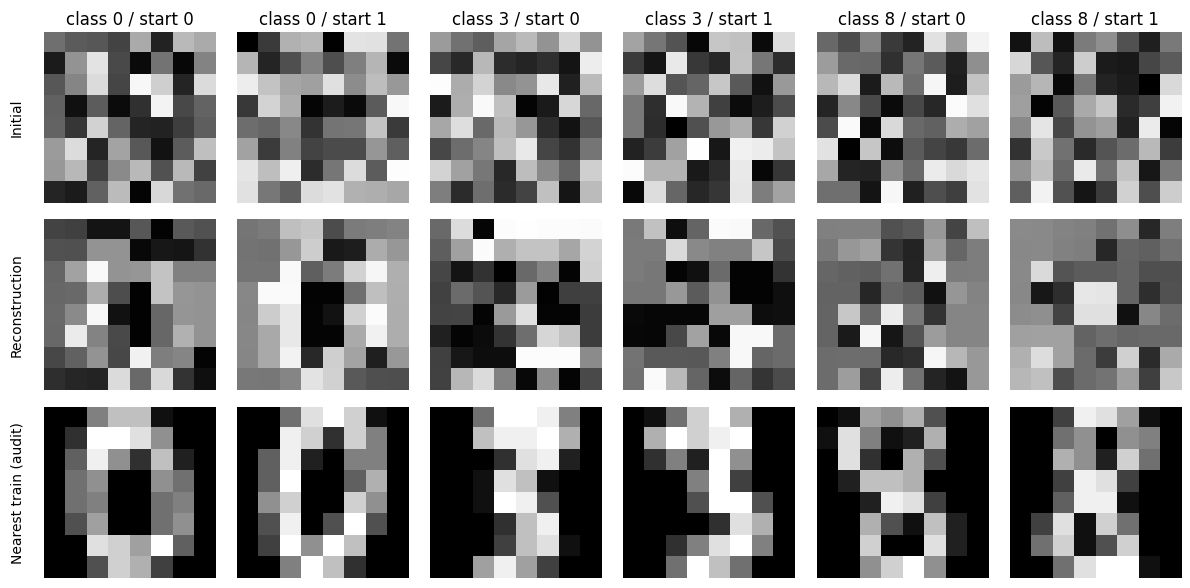

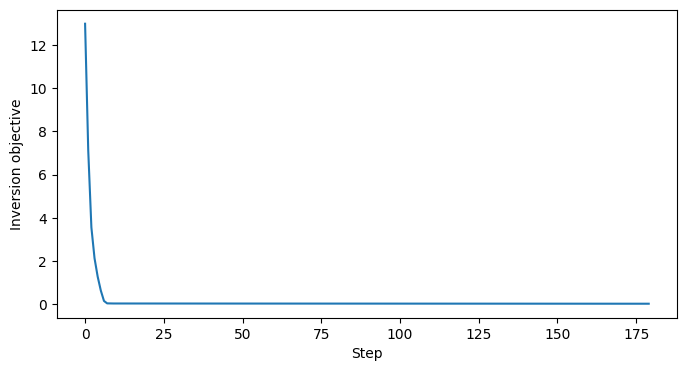

In [ ]:
inverse_probe_x = torch.full((2,64), .5, requires_grad=True)
inverse_probe = inversion_loss(clean, inverse_probe_x, torch.tensor([0,1]))
if inverse_probe is None:
    pending("D1")
else:
    # --- Sanity-check: loss должен быть скаляром, а градиент — течь до x ---
    assert inverse_probe.ndim == 0                       # скаляр, а не тензор с оставшимися размерностями
    grad = torch.autograd.grad(inverse_probe, inverse_probe_x)[0]
    assert torch.isfinite(grad).all() and grad.abs().sum() > 0
    # Градиент конечен (нет nan/inf из-за log(0)) и не нулевой (связь x→loss не порвана).

    # --- Замораживаем веса модели: обучаем только x ---
    before_weights = [p.detach().clone() for p in clean.parameters()]  # снимок для проверки
    for p in clean.parameters():
        p.requires_grad_(False)                          # модель НЕ должна обучаться

    # --- 6 реконструкций: по 2 старта для классов 0, 3, 8 ---
    classes = torch.tensor([0,0,3,3,8,8], dtype=torch.long)
    torch.manual_seed(70)                                # фиксируем начальный шум для воспроизводимости
    inv_x = torch.rand((6,64), requires_grad=True)       # старт со случайного шума в [0,1]
    initial = inv_x.detach().numpy().copy()              # сохраняем старт для визуализации
    opt_x = torch.optim.Adam([inv_x], lr=.04)            # оптимизируем ТОЛЬКО пиксели
    inv_hist = []
    for _ in range(180):
        opt_x.zero_grad()
        loss = inversion_loss(clean, inv_x, classes)
        loss.backward(); opt_x.step()
        # Клиппинг в [0,1] делается отдельно, а не внутри loss:
        # иначе бы разорвали градиент (clamp не дифференцируем вне диапазона).
        with torch.no_grad():
            inv_x.clamp_(0,1)
        inv_hist.append(loss.item())
    recon = inv_x.detach().numpy()

    # Проверка: веса clean не изменились (мы обучали только x).
    assert all(torch.equal(p, old) for p,old in zip(clean.parameters(), before_weights))
    for p in clean.parameters():
        p.requires_grad_(True)                           # возвращаем модели исходное состояние

    # --- Аудиторский анализ: сравнение реконструкций с train и test ---
    # Это НЕ часть атаки: атакующий не имеет доступа к Xtr/Xte.
    # Аудитор проверяет, не «утекла» ли конкретная train-запись.
    rows, nearest_train = [], []
    for i, cls in enumerate(classes.numpy()):
        tri = np.flatnonzero(ytr == cls); tei = np.flatnonzero(yte == cls)
        # Одинаковое число кандидатов: иначе «ближайший train» мог бы выигрывать
        # просто потому, что train-примеров больше, чем test.
        nref = min(len(tri), len(tei)); tri, tei = tri[:nref], tei[:nref]
        # MSE между реконструкцией и каждым кандидатом (усреднение по 64 пикселям).
        dtr = ((Xtr[tri]-recon[i])**2).mean(1)
        dte = ((Xte[tei]-recon[i])**2).mean(1)
        nearest_train.append(Xtr[tri[dtr.argmin()]])     # для визуализации в третьей строке
        rows.append({
            "class": int(cls),
            "restart": i%2,                              # 0 — первый старт класса, 1 — второй
            # Confidence: насколько модель уверена, что реконструкция — это нужный класс.
            # Если близко к 1 — оптимизация сработала.
            "confidence": float(probs(clean,recon[i:i+1])[0,cls]),
            # MSE до ближайшего train-примера того же класса.
            "nearest_train_MSE": float(dtr.min()),
            "nearest_test_MSE": float(dte.min()),
            "nref_each": nref                            # сколько кандидатов было в каждой группе
        })
    results["inversion"] = rows
    display(pd.DataFrame(rows))

    fig, ax = plt.subplots(3,6, figsize=(12,6))
    for i in range(6):
        for r, arr in enumerate([initial, recon, np.array(nearest_train)]):
            ax[r,i].imshow(arr[i].reshape(8,8), cmap="gray", vmin=0, vmax=1)
            ax[r,i].axis("off")
        ax[0,i].set_title(f"class {classes[i].item()} / start {i%2}")
    for r,label in enumerate(["Initial", "Reconstruction", "Nearest train (audit)"]):
        ax[r,0].text(-.2,.5,label, transform=ax[r,0].transAxes, rotation=90, va="center")
    plt.tight_layout(); plt.show()

    # --- Кривая сходимости loss по шагам ---
    plt.plot(inv_hist); plt.xlabel("Step"); plt.ylabel("Inversion objective"); plt.show()

Оптимизация сработала. Loss вышел на минимум, реконструкция удовлетворяет всем трём требованиям: модель уверена в классе (низкий CE), пиксели не разлетелись (низкий L2), картинка гладкая (низкий TV).

У всех реконструкций confidence ≈ 1.0. Значит, модель смотрит на полученную картинку и говорит «это точно класс c». Атака успешно синтезировала вход, который модель классифицирует как заданный класс.

Реконструкция похожа на «типичную» цифру класса, а не на конкретную train-запись.

Если бы произошла утечка конкретной записи, мы увидели бы: nearest_train_MSE ≈ 0 (реконструкция почти совпала с train-примером), а nearest_test_MSE заметно больше. Здесь такого нет.

## E. Model extraction: локальный API с бюджетом

Атакующий хочет скопировать модель, не имея доступа к её весам. У него есть только API: он может посылать входные картинки и получать ответы (вероятности или метки).

Цель — обучить свою собственную модель-клон, которая ведёт себя так же, как жертва, на любых входах. Не восстановить точные веса жертвы (это было бы сложнее и требовало бы других методов), а именно скопировать её функцию x → y

Что атакующий видит:

свои query-входы (картинки, которые он сам посылает);

ответы API на эти входы — soft (вероятности) или hard (только argmax-метка).

НЕ видит:

истинные метки ytr, yte, y[pool_ids] — они ему недоступны;

внутренние веса жертвы;

train-данные жертвы.

Важно: fit клона использует только пары (query, ответ_API). Никаких истинных меткок ни в одной строке.

Чтобы не платить за одни и те же запросы повторно, один раз получаем 500 ответов и кэшируем их.
Модели с бюджетом 50/150/500 получают только соответствующий префикс ответов.
В эксплуатации метрики аудита потребовали бы отдельного доступа оценщика;
здесь он считает fidelity на test напрямую и не расходует бюджет атакующего.

### Задание E1. Дистилляция

Реализуйте soft cross-entropy по logits student и распределению teacher.
Не передавайте вероятности как logits в `cross_entropy`.
Для hard-label варианта используется стандартная cross-entropy с argmax teacher.

**Knowledge distillation** (дистилляция знаний) — это приём обучения одной модели (**student**) на предсказаниях другой (**teacher**). Не на истинных метках, а именно на **выходе учителя**.

## Обычное обучение vs дистилляция

**Обычное обучение (supervised):** учится попадать в **истинную метку**. Например, для цифры 3 — «цель = класс 3».

**Дистилляция:** учится попадать в **распределение вероятностей учителя**.

Эта дополнительная информация называется **dark knowledge**.

## Что делает `distill_loss`

Считает **soft cross-entropy** между логитами студента и распределением вероятностей учителя.

Формула:
$$
\text{loss} = -\frac{1}{n} \sum_{i=1}^{n} \sum_{k=1}^{K} \text{teacher\_p}_{i,k} \cdot \log(\text{softmax}(\text{logits}_i)_k)
$$

По-русски:
- для каждого примера в батче берём распределение учителя `teacher_p[i]` и логарифм softmax студента `log_softmax(logits[i])`;
- перемножаем поэлементно и суммируем по классам — это скалярное произведение «распределение учителя × логарифм распределения студента»;
- усредняем по батчу;
- берём со знаком минус.

In [ ]:
def distill_loss(logits, teacher_p):
    # logits: (n, K) — сырые выходы student ДО softmax.
    # teacher_p: (n, K) — вероятности от teacher (сумма по K = 1).

    # log_softmax по классам
    log_p = F.log_softmax(logits, dim=1)                # (n, K)

    # Поэлементное произведение teacher_p * log_p:
    #   если student уверен в том же, что и teacher — большие положительные слагаемые;
    #   если student уверен в другом — маленькие или отрицательные.
    # .sum(1) — сумма по классам (K), даёт (n,).
    # .mean() — усреднение по батчу.
    # Минус в начале — потому что мы максимизируем log-likelihood, а loss минимизируем.
    return -(teacher_p * log_p).sum(1).mean()

,queries_available,output,fidelity,clone_accuracy,victim_accuracy
0,50,soft,0.766,0.754,0.962
1,50,hard,0.734,0.730,0.962
2,150,soft,0.930,0.912,0.962
3,150,hard,0.894,0.880,0.962
4,500,soft,0.962,0.952,0.962
5,500,hard,0.950,0.938,0.962


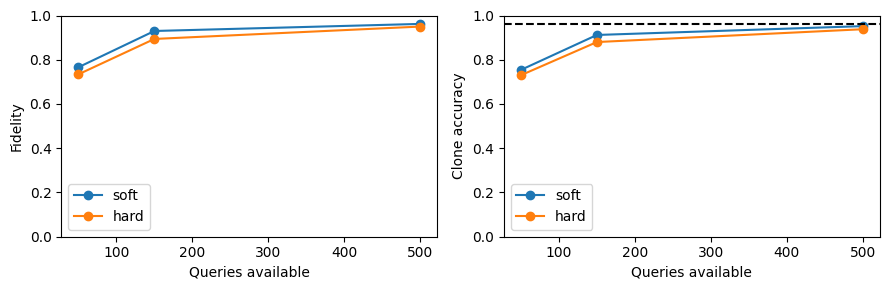

Всего запросов к API в этом опыте: 500


In [ ]:
class LocalAPI:
    def __init__(self, model, budget=500):
        # Имя с двумя подчёркиваниями — name-mangling: снаружи обратиться к api.__model нельзя.
        # Это символическая граница "атакующий не видит веса"
        self.__model = model
        self.budget, self.used = budget, 0

    def query(self, x):
        # Проверка бюджета ДО инкремента: иначе можно было бы выйти за лимит на один вызов.
        if self.used + len(x) > self.budget:
            raise RuntimeError("Query budget exceeded")
        self.used += len(x)
        return probs(self.__model, x)   # возвращает ТОЛЬКО вероятности, не логиты и не метки


# Sanity-check distill_loss: logits=0 → равномерный softmax; teacher=0.1 по всем классам → тоже равномерный.
# CE между двумя равномерными по K классам = log(K) = log(10).
dl_probe = distill_loss(torch.zeros(2,10, requires_grad=True), torch.full((2,10), .1))
if dl_probe is None:
    pending("E1")
else:
    assert torch.isclose(dl_probe.detach(), torch.tensor(np.log(10), dtype=torch.float32))

    # --- Один раз делаем 500 запросов и кэшируем ответы ---
    api = LocalAPI(clean, budget=500)
    # Перемешиваем pool: чтобы разные бюджеты были НЕ "первые 50 из pool", а случайная подвыборка.
    # rng с фиксированным seed — воспроизводимость.
    order = np.random.default_rng(80).permutation(len(Xpool))
    queries = Xpool[order]
    # Один пакетный запрос на 500 примеров: 500 уникальных query-входов.
    cached_answers = api.query(queries)
    assert api.used == 500

    # Проверка: бюджет реально enforced, следующий запрос упадёт.
    try:
        api.query(queries[:1])
        raise AssertionError("Budget is not enforced")   # если мы здесь — api не проверяет бюджет
    except RuntimeError:
        pass

    # Аудиторские метки жертвы на test (нужны для fidelity). Атакующий их не имеет —
    victim_test_labels = probs(clean, Xte).argmax(1)

    extraction_rows = []
    for budget in [50,150,500]:
        for mode in ["soft", "hard"]:
            qx, qp = tensor(queries[:budget]), tensor(cached_answers[:budget])

            # Клон — маленькая модель (width=32), отдельный seed 81.
            # Одинаковая архитектура и seed для всех бюджетов/режимов → сравнение честное.
            student = new_model(64,10,seed=81,width=32)
            optimizer = torch.optim.Adam(student.parameters(), lr=.01, weight_decay=1e-4)

            for _ in range(160):
                optimizer.zero_grad()
                logits = student(qx)
                # soft: дистилляция на распределении учителя.
                # hard: обычная CE на argmax учителя — то же "сырьё", но без "тёмного знания".
                loss = distill_loss(logits, qp) if mode == "soft" else F.cross_entropy(logits, qp.argmax(1))
                loss.backward(); optimizer.step()

            # Предсказания клона на test (argmax вероятностей).
            clone_pred = probs(student.eval(), Xte).argmax(1)

            extraction_rows.append({
                "queries_available": budget,
                "output": mode,
                # Fidelity: насколько клон совпадает с ЖЕРТВОЙ. Метки = victim_test_labels.
                # Это ключевая метрика атаки: цель — скопировать поведение, а не "правильно решать".
                "fidelity": accuracy_score(victim_test_labels, clone_pred),
                # Accuracy: насколько клон сам по себе правилен на ИСТИННЫХ метках yte.
                # Может быть ниже fidelity, если жертва ошибается и клон копирует эти ошибки.
                "clone_accuracy": accuracy_score(yte, clone_pred),
                "victim_accuracy": baseline_acc,           # для сравнения: эталон жертвы
            })

    results["extraction"] = extraction_rows
    display(pd.DataFrame(extraction_rows))

    # --- Две панели: fidelity vs clone accuracy ---
    fig, ax = plt.subplots(1,2, figsize=(9,3))
    ef = pd.DataFrame(extraction_rows)
    for mode in ["soft","hard"]:
        sub = ef[ef.output == mode]
        # Левая: как fidelity растёт с бюджетом для soft и hard.
        ax[0].plot(sub.queries_available, sub.fidelity, "o-", label=mode)
        # Правая: как accuracy клона растёт с бюджетом.
        ax[1].plot(sub.queries_available, sub.clone_accuracy, "o-", label=mode)
    for a in ax:
        a.set(xlabel="Queries available", ylim=(0,1)); a.legend()
    ax[0].set_ylabel("Fidelity"); ax[1].set_ylabel("Clone accuracy")
    # Горизонталь на правой панели — точность жертвы. Верхняя граница для clone_accuracy.
    ax[1].axhline(baseline_acc, color="black", linestyle="--")
    plt.tight_layout(); plt.show()
    print("Всего запросов к API в этом опыте:", api.used)

## F. Протокол и отчёт

### Задание F1. Анализ и расширение

В основной части сформулируйте по одному выводу для A–E и один отрицательный/неоднозначный результат.
Для каждого укажите модель угроз, доступ атакующего, контроль, числитель и знаменатель метрики,
а также то, что из результата НЕ следует.

Выберите один вариант:

- **Backdoor**: сравните доли 0.05, 0.15, 0.25 на трёх seed; оставьте фиксированными патч и target.
- **Membership**: повторите оба режима на трёх seed; сравните AUC и PPV при pi=0.01/0.1/0.5.
- **Inversion**: сравните TV=0 и TV=0.05 на трёх seed; сопоставьте confidence и видимость класса.
- **Extraction**: повторите кривые бюджетов на трёх seed; сравните разброс soft/hard fidelity.

Выбор варианта согласуется до просмотра итогового test. При изменении гиперпараметров используйте
validation или отдельный development-стенд. Не используйте обучающую метку public pool для клона.
Покажите mean ± sample SD; не называйте интервал mean ± SD доверительным.
Не исключайте «неудачные» seed.

### Вопросы

- **Целостность данных**: чем случайная ошибка разметки отличается от намеренного poisoning?
- **Backdoor**: почему высокая clean accuracy не исключает высокий ASR? Зачем исключать target из знаменателя?
- **MIA**: зачем нужен shadow? Почему порог на target test означает утечку методики оценки?
- **Приватность**: почему AUC=0.5 у одной атаки не доказывает отсутствие утечек?
- **Inversion**: почему высокая confidence и похожая картинка не доказывают кражу конкретной записи?
- **Extraction**: почему модель-клон может иметь высокую fidelity, но низкую accuracy?
- **Защита**: почему weight decay и ограничение API не дают гарантии differential privacy?

### Что сдавать

Сдайте заполненный `.ipynb` с выводами и графиками, таблицу результатов, версии среды,
seed и краткое заключение (до 2 страниц). Все TODO должны быть реализованы.
Если блок пропущен, строка «не выполнено» не является результатом эксперимента.
Отсутствие ошибок при Run All само по себе не означает выполнения лабораторной.

По seed:


,rate,seed,clean_accuracy,ASR
0,0.05,0,0.946,0.817778
1,0.05,1,0.956,0.988889
2,0.05,2,0.942,0.955556
3,0.15,0,0.942,0.980000
4,0.15,1,0.936,0.973333
5,0.15,2,0.958,0.962222
6,0.25,0,0.950,1.000000
7,0.25,1,0.924,0.995556
8,0.25,2,0.930,0.993333



mean ± sample SD:


,rate,clean_acc_mean,clean_acc_sd,ASR_mean,ASR_sd
0,0.05,0.948000,0.007211,0.920741,0.090713
1,0.15,0.945333,0.011372,0.971852,0.008981
2,0.25,0.934667,0.013614,0.996296,0.003395


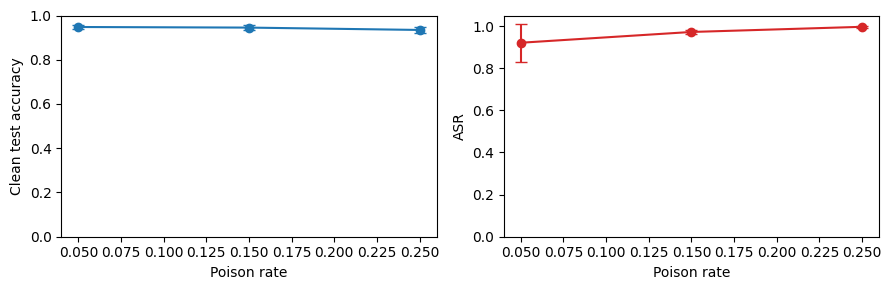

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.nn import functional as F
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# --- Воспроизводимость на уровне всего эксперимента ---
torch.set_num_threads(2)
torch.use_deterministic_algorithms(True)

# --- Минимальные утилиты (дублируем, чтобы блок не зависел от предыдущих ячеек) ---
def tensor(x):
    return torch.as_tensor(x, dtype=torch.float32)

def new_model(d, k, seed, width=64):
    torch.manual_seed(seed)
    return nn.Sequential(nn.Linear(d, width), nn.ReLU(),
                         nn.Linear(width, width), nn.ReLU(), nn.Linear(width, k))

def fit(x, y, k=10, epochs=140, wd=1e-4, seed=42, width=64):
    model = new_model(x.shape[1], k, seed, width)
    opt = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=wd)
    xt = tensor(x)
    yt = torch.as_tensor(y, dtype=torch.long)
    for _ in range(epochs):
        opt.zero_grad()
        loss = F.cross_entropy(model(xt), yt)
        loss.backward(); opt.step()
    return model.eval()

def probs(model, x):
    with torch.no_grad():
        return model(tensor(x)).softmax(1).numpy()

def trigger(x):
    z = x.copy().reshape(-1, 8, 8)
    z[:, -2:, -2:] = 1
    return z.reshape(-1, 64)

def poison_data(x, y, rate, target=0, seed=42):
    x_p, y_p = x.copy(), y.copy()
    n_change = int(np.floor(rate * len(y)))
    rng = np.random.default_rng(seed)
    candidates = np.flatnonzero(y != target)
    chosen = rng.choice(candidates, size=n_change, replace=False)
    x_p[chosen] = trigger(x_p[chosen])
    y_p[chosen] = target
    return x_p, y_p

def targeted_asr(pred, y, target):
    mask = y != target
    if mask.sum() == 0:
        return float("nan")
    return float((pred[mask] == target).mean())

# --- Данные: фиксированное разбиение, одинаковое для всех seed атаки ---
digits = load_digits()
X = (digits.data / 16.0).astype(np.float32)
y = digits.target
ids = np.arange(len(y))
rest, test_ids = train_test_split(ids, test_size=500, random_state=42, stratify=y)
train_ids, _ = train_test_split(rest, train_size=600, random_state=44, stratify=y[rest])
Xtr, ytr = X[train_ids], y[train_ids]
Xte, yte = X[test_ids], y[test_ids]

# --- Основной эксперимент: 3 seed × 3 доли отравления ---
RATES = [0.05, 0.15, 0.25]
SEEDS = [0, 1, 2]
rows = []

for rate in RATES:
    for seed in SEEDS:
        # Данные отравления зависят только от seed (не от seed модели):
        # так мы изолируем вариативность от выбора индексов и от инициализации модели.
        xp, yp = poison_data(Xtr, ytr, rate=rate, target=0, seed=100 + seed)
        # Модель — от seed: разная инициализация и порядок не важен (Adam на полном батче).
        m = fit(xp, yp, seed=200 + seed)
        pc = probs(m, Xte).argmax(1)
        pt = probs(m, trigger(Xte)).argmax(1)
        rows.append({
            "rate": rate, "seed": seed,
            "clean_accuracy": accuracy_score(yte, pc),
            "ASR": targeted_asr(pt, yte, target=0),
        })

df = pd.DataFrame(rows)

# --- Агрегация: mean ± sample SD по 3 seed для каждой доли ---
summary = df.groupby("rate").agg(
    clean_acc_mean=("clean_accuracy", "mean"),
    clean_acc_sd=("clean_accuracy", "std"),     # ddof=1 по умолчанию — sample SD
    ASR_mean=("ASR", "mean"),
    ASR_sd=("ASR", "std"),
).reset_index()

print("По seed:")
display(df)
print("\nmean ± sample SD:")
display(summary)

# --- Визуализация с error bars ---
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
ax[0].errorbar(summary["rate"], summary["clean_acc_mean"],
               yerr=summary["clean_acc_sd"], marker="o", capsize=4)
ax[0].set(xlabel="Poison rate", ylabel="Clean test accuracy", ylim=(0, 1))
ax[1].errorbar(summary["rate"], summary["ASR_mean"],
               yerr=summary["ASR_sd"], marker="o", capsize=4, color="C3")
ax[1].set(xlabel="Poison rate", ylabel="ASR", ylim=(0, 1.05))
plt.tight_layout(); plt.show()

Clean accuracy почти не зависит от rate: 0.924–0.958 во всех девяти прогонах, никакого тренда. Отравление меток не ломает модель «в среднем».

Что это значит. При rate=0.05 атака нестабильна: с одним seed ASR почти 0.82, с другим — 0.99. Всё зависит от того, попали ли в отравленный набор «удачные» примеры

ASR монотонно растёт с rate, но его стабильность растёт ещё быстрее. Если атакующий ограничен малым бюджетом отравления, ему придётся либо подбирать seed, либо мириться с высокой дисперсией. При rate ≥ 0.15 атака уже надёжна.

Clean accuracy при этом демонстрирует слабый отрицательный тренд: 0.948 → 0.945 → 0.935 в среднем по seed. Это в пределах 1–2 п.п., на уровне SD (clean_acc_sd = 0.007–0.014). Строго говоря, «модель не портится» здесь означает «модель не портится настолько, чтобы это было заметно». Некоторое снижение есть, и оно логично: мы портим часть обучающих меток, что не может не сказаться на обобщении. Но это снижение на 1.3 п.п. при 25% отравления — ничто по сравнению с ASR = 1.0.

**A. Label flipping.** Атакует порча меток, доступ — обучающий набор. Контроль — rate=0. `clean_test_accuracy` = правильно классифицированные / 500 test. При 30% испорченных меток точность падает, но не до нуля: случайный сдвиг меток симметричен, классы перемешиваются, но сигнал остаётся. НЕ следует: что poisoning вообще безвреден — мы проверили только случайный сдвиг, целенаправленный был бы хуже.

**B. Backdoor.** Атакует добавление патча и смена метки на target. Доступ — обучающие данные. Контроль — чистая модель на том же триггере (ASR=0). ASR = нетаргетные, ответившие target / все нетаргетные. ASR=1.0 у отравленной модели при clean accuracy 0.956 (у чистой 0.962). НЕ следует: что модель «сломана» — на нормальных входах она работает штатно.

**C. Membership inference.** Атакует угадывание членства по выходу модели. Доступ — query + истинная метка записи. Контроль — shadow-модель для порога. TPR = пойманные members / 400 members. AUC 0.67 (Overfit) vs 0.62 (Regularized), gap 0.22 vs 0.17. Но `TPR@FPR≤1%` = 0.00 и 0.01. НЕ следует: что атака практически опасна — при π=0.01 PPV ≈ 6%, и что weight decay — это DP.

**D. Model inversion.** White-box атакующий синтезирует вход под класс. Доступ — веса и градиенты, train недоступен. Контроль — два старта на класс + аудиторское сравнение с train/test. Confidence = `p(c|x)`, ключевые метрики — MSE. Confidence ≈ 1.0, MSE до train ≈ MSE до test (0.11–0.17 в обоих). НЕ следует: что украдена конкретная train-запись — реконструкция близка ко всем цифрам класса одинаково.

**E. Model extraction.** Копирование поведения через API. Доступ — query с бюджетом. Контроль — три бюджета при фиксированной архитектуре. Fidelity = совпадения argmax клона и жертвы / 500 test. 500 soft-запросов дают fidelity 0.962 (= victim_accuracy), soft > hard (до +3.6 п.п.), насыщение к 150. НЕ следует: что fidelity = accuracy — клон наследует ошибки жертвы, clone_accuracy 0.952 < 0.962.

**Отрицательный результат.** Fine-tuning на чистых данных не устранил backdoor: ASR остался 0.998 (было 1.000) после 40 эпох на 197 чистых примерах. Рецепт «переобучи на чистых данных — backdoor исчезнет» здесь не работает. Причины: мало данных, малый lr, триггер в весах, которые чистые данные не задевают.

## Ответы на вопросы

**Целостность данных.** Случайная ошибка разметки — независимый шум, метки портятся без цели, классы смещаются симметрично, модель в среднем не смещается ни к какому классу. Намеренный poisoning — целенаправленный, атакующий выбирает, какие метки и на что менять, чтобы добиться конкретного поведения модели (например, все 1→7). Случайный шум ухудшает обобщение равномерно, poisoning создаёт смещённое представление о конкретных классах.

**Backdoor.** Clean accuracy и ASR измеряют разное. Первая — поведение на нормальных входах, второй — на входах с триггером. Модель может идеально работать в первом режиме и полностью «переключаться» во втором, потому что backdoor — это отдельный выученный путь активации. Target из знаменателя исключают, потому что истинные target-примеры и так должны попадать в target — считать их «успехом атаки» было бы жульничеством и завышало бы ASR.

**MIA.** Shadow нужен, чтобы выбрать порог, не видя истинных меток target. Если порог подбирать по target test, мы используем информацию, которой в реальной атаке у атакующего нет, и измеряем не силу атаки, а свою осведомлённость. Это называется утечкой методики оценки и завышает метрики.

**Приватность.** AUC=0.5 означает, что конкретная атака не отличает members от nonmembers лучше случайного. Это не значит, что утечек нет — другая атака (LiRA, атаки через градиенты, атаки через другие каналы) может работать. Одна неудавшаяся атака — не доказательство приватности, отсутствие утечки доказывается формально (например, DP).

**Inversion.** Высокая confidence означает, что модель уверена в синтезированном входе, — то есть атака сработала, но это говорит о работе оптимизации, а не о краже данных. Похожая картинка может быть просто обобщённым прототипом класса: все цифры одного класса похожи, и реконструкция похожа на всех. Чтобы говорить о краже конкретной записи, нужен отдельный аудит: MSE до train должно быть заметно меньше, чем до test. В нашем эксперименте этого не было.

**Extraction.** Клон учится на ответах жертвы, а не на истинных метках. Если жертва ошибается на 4% примеров, клон копирует эти ошибки — fidelity остаётся высокой (он «согласен» с жертвой), а accuracy падает (он не совпадает с истиной). Fidelity измеряет верность копии, accuracy — правильность классификатора. Атакующему важна именно fidelity: он хочет заменить жертву, а не улучшить её.

**Защита.** Weight decay ослабляет конкретные эмпирические атаки (в нашем эксперименте MIA упала с 0.67 до 0.62), но не даёт математических гарантий. Другая, более сильная атака может показать больше утечки на той же модели. Ограничение API (rate-limit, бюджет) затрудняет extraction, но не делает его невозможным — атакующий распределит запросы по времени или аккаунтам. DP даёт формальные гарантии `(ε, δ)` против любого атакующего, но требует обучения с шумом и клиппингом, что снижает точность. Ни weight decay, ни rate-limit не являются DP.

In [ ]:
required = ["baseline","label_flipping","backdoor","backdoor_defense","membership","inversion","extraction"]
missing = [name for name in required if name not in results]
print("Разделы с результатами:", list(results))
print("Незавершённые разделы:", missing)
print(f"Время исполнения: {time.perf_counter()-START:.1f} с")
# По желанию сохраните результаты в рабочую папку Jupyter:
# from pathlib import Path
# Path("lecture09_results.json").write_text(json.dumps(results, ensure_ascii=False, indent=2), encoding="utf-8")